In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from pathlib import Path
from utils import GESTURES, N_FRAMES

In [2]:
GESTURES

['hello', 'no_hand', 'calling', 'pointing', 'so_so']

In [3]:
X = []
y = []

In [4]:
for label, gesture in enumerate(GESTURES):
    path = Path('dataset') / gesture
    if path.is_dir():
        sequences = list(path.glob('*-sequence.npy'))
        for sequence_path in sequences:
            sequence = np.load(sequence_path)
            X.append(sequence)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(400, 60, 44) (400,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
num_clases = len(np.unique(y))
num_clases

5

In [7]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(N_FRAMES, X.shape[2])),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.5), 
    
    Dense(num_clases, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\Chava\miniconda3\envs\mlfinal_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       106,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,101 (547.27 KB)

 Trainable params: 140,101 (547.27 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

In [9]:
model.save('./models/trained_model.keras')

In [10]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


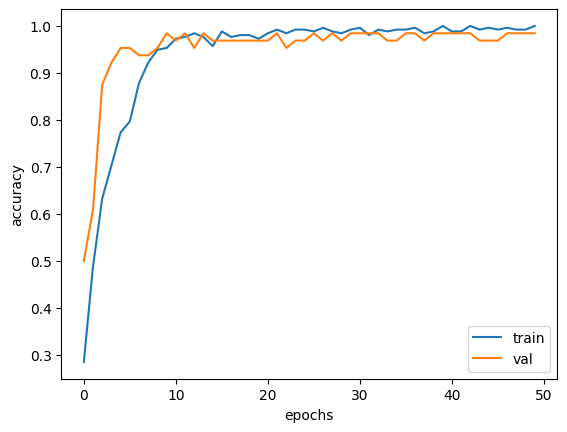

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.show()

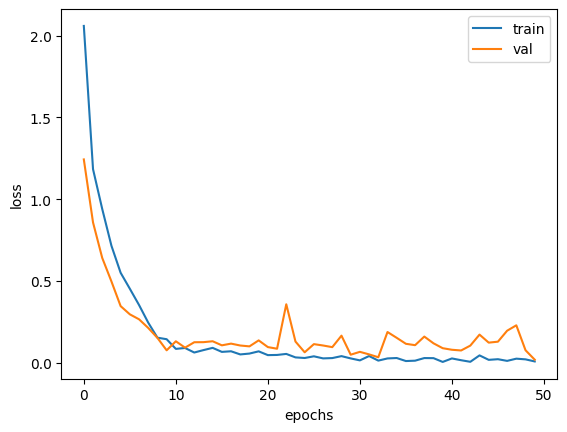

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

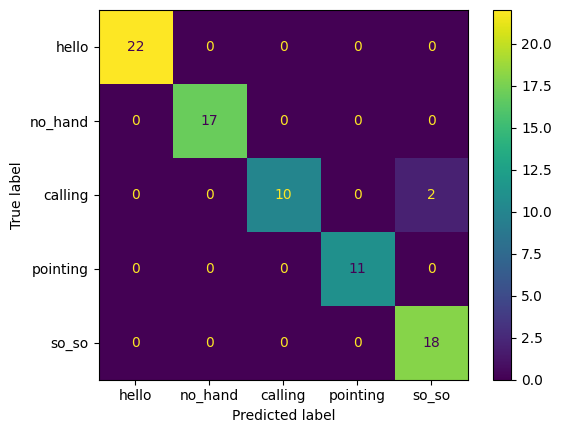

In [13]:
id_to_name = {i: name for i, name in enumerate(GESTURES)}
y_test_names = np.array([id_to_name[i] for i in y_test])
y_pred_names = np.array([id_to_name[i] for i in y_pred])


ConfusionMatrixDisplay(
    confusion_matrix(y_test_names, y_pred_names, labels=GESTURES),
    display_labels=GESTURES
).plot()
plt.show()